In [28]:
import torch
import matplotlib.pyplot as plt

In [2]:
train_embds = torch.load("../data/embeddings/train_dinov2_vits14_embeddings.pt")
test_embds = torch.load("../data/embeddings/test_dinov2_vits14_embeddings.pt")

In [3]:
features = train_embds["features"]
centers = train_embds["centers"]

In [24]:
unique_centers, inverse = torch.unique(centers, return_inverse=True)
K = unique_centers.size(0)
D = features.size(1)

means = torch.zeros(K, D)
counts = torch.zeros(K)

means.index_add_(0, inverse, features)
counts.index_add_(0, inverse, torch.ones_like(inverse, dtype=torch.float))

means = means / counts.unsqueeze(1)
diff = features - means[inverse]
var = torch.zeros(K, D)

var.index_add_(0, inverse, diff**2)
var = var / counts.unsqueeze(1)

stds = torch.sqrt(var)

In [26]:
means.shape, stds.shape

(torch.Size([3, 384]), torch.Size([3, 384]))

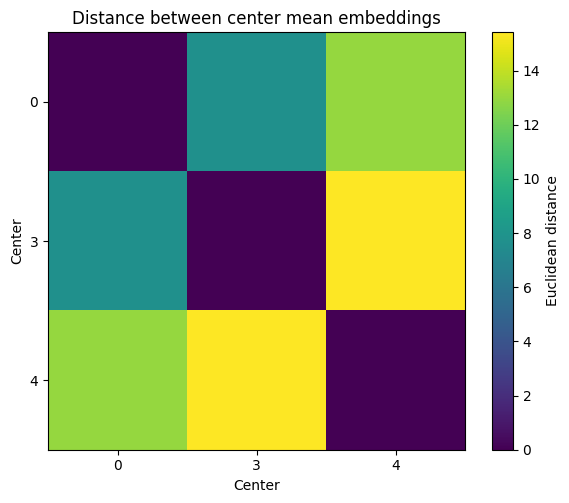

In [29]:
dist_matrix = torch.cdist(means, means, p=2)

plt.figure(figsize=(6, 5))
plt.imshow(dist_matrix.numpy())
plt.colorbar(label="Euclidean distance")
plt.xticks(range(K), unique_centers.tolist())
plt.yticks(range(K), unique_centers.tolist())
plt.xlabel("Center")
plt.ylabel("Center")
plt.title("Distance between center mean embeddings")
plt.tight_layout()

In [31]:
global_std = features.std(dim=0).mean()
mean_dist = dist_matrix[~torch.eye(K, dtype=torch.bool)].mean()

print("Average inter-center mean distance:", mean_dist.item())
print("Average feature std:", global_std.item())
print("Ratio:", (mean_dist / global_std).item())

Average inter-center mean distance: 12.042827606201172
Average feature std: 1.4216357469558716
Ratio: 8.47110652923584
